In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

I'm loading in `unique_us_owners_points` from the previous notebook, which has owner mailing address point geometry as the geometry.

To note: the `geometry` column is the original `owner_geometry` column - it changed when saving to gpkg. I will rename it back to avoid confusion

In [4]:
unique_us_owners_points = gpd.read_file('geodata_clean/unique_us_owners_points.gpkg')

len(unique_us_owners_points)

37869

In [6]:
unique_us_owners_points = unique_us_owners_points.rename(columns={'geometry': 'owner_geometry'}).set_geometry('owner_geometry')

In [10]:
# filter out failed geocode lookup rows

print(unique_us_owners_points.geometry.isna().sum())
print(unique_us_owners_points.geometry.is_empty.sum())

us_owners_for_clustering = unique_us_owners_points[~unique_us_owners_points.geometry.is_empty]

len(us_owners_for_clustering)

0
122


37747

Reproject to a projected meter-based CRS for distance-based clustering, like EPSG:5070 (NAD83/Conus Albers) for the continental US

Then calculate the coordinates in meters (rather than degrees)

In [11]:
us_owners_for_clustering.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [12]:
# also going to shorten the variable name for brevity

us_owners_5070 = us_owners_for_clustering.to_crs('EPSG:5070')

coords = us_owners_5070.geometry.get_coordinates().values
coords

array([[-10403133.87166825,   6523497.07730471],
       [-10413864.66230132,   6529214.69361497],
       [-10401566.94148986,   6528844.44184057],
       ...,
       [  -955787.85971586,   1005296.15101431],
       [  -972998.63840834,   1012286.6570164 ],
       [  3351252.66240405,     51158.00156206]], shape=(37747, 2))

First, I'll try DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

`eps` = the maximum distance between two items to be considered within the neighborhood of each other

`min_samples` = number of samples in a neighborhood for a point to be considered a core point
- higher value -> denser clusters
- lower value -> sparser clusters

In [ ]:
# test out a range of eps and min_sample values
# because I used a meter-based CRS for calculations, we need to define eps in terms of m (or km)

from sklearn.cluster import DBSCAN

for eps_km in [15, 20, 25, 50, 75]:
    for min_sample in [3, 5, 10, 20]:
        db = DBSCAN(eps=eps_km * 1000, min_samples=min_sample).fit(coords)
        n_clust = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
        n_noise = list(db.labels_).count(-1)
        print(f"eps={eps_km}km, min_samples={min_sample}: {n_clust} clusters, {n_noise} noise ({n_noise/len(db.labels_):.1%})")

eps=15km, min_samples=3: 813 clusters, 2292 noise (6.1%)
eps=15km, min_samples=5: 480 clusters, 3538 noise (9.4%)
eps=15km, min_samples=10: 244 clusters, 5569 noise (14.8%)
eps=15km, min_samples=20: 146 clusters, 7892 noise (20.9%)
eps=20km, min_samples=3: 608 clusters, 1518 noise (4.0%)
eps=20km, min_samples=5: 388 clusters, 2459 noise (6.5%)
eps=20km, min_samples=10: 213 clusters, 4109 noise (10.9%)
eps=20km, min_samples=20: 139 clusters, 6213 noise (16.5%)
eps=25km, min_samples=3: 453 clusters, 1035 noise (2.7%)
eps=25km, min_samples=5: 294 clusters, 1751 noise (4.6%)
eps=25km, min_samples=10: 186 clusters, 3054 noise (8.1%)
eps=25km, min_samples=20: 131 clusters, 4923 noise (13.0%)
eps=50km, min_samples=3: 126 clusters, 210 noise (0.6%)
eps=50km, min_samples=5: 86 clusters, 386 noise (1.0%)
eps=50km, min_samples=10: 61 clusters, 907 noise (2.4%)
eps=50km, min_samples=20: 61 clusters, 1770 noise (4.7%)
eps=75km, min_samples=3: 55 clusters, 86 noise (0.2%)
eps=75km, min_samples=5: 35

64 clusters, 12135 noise points
cluster_id
0     3763
8     2410
11    1534
17    1422
15    1347
19    1273
3      924
13     893
38     680
34     679
Name: count, dtype: int64


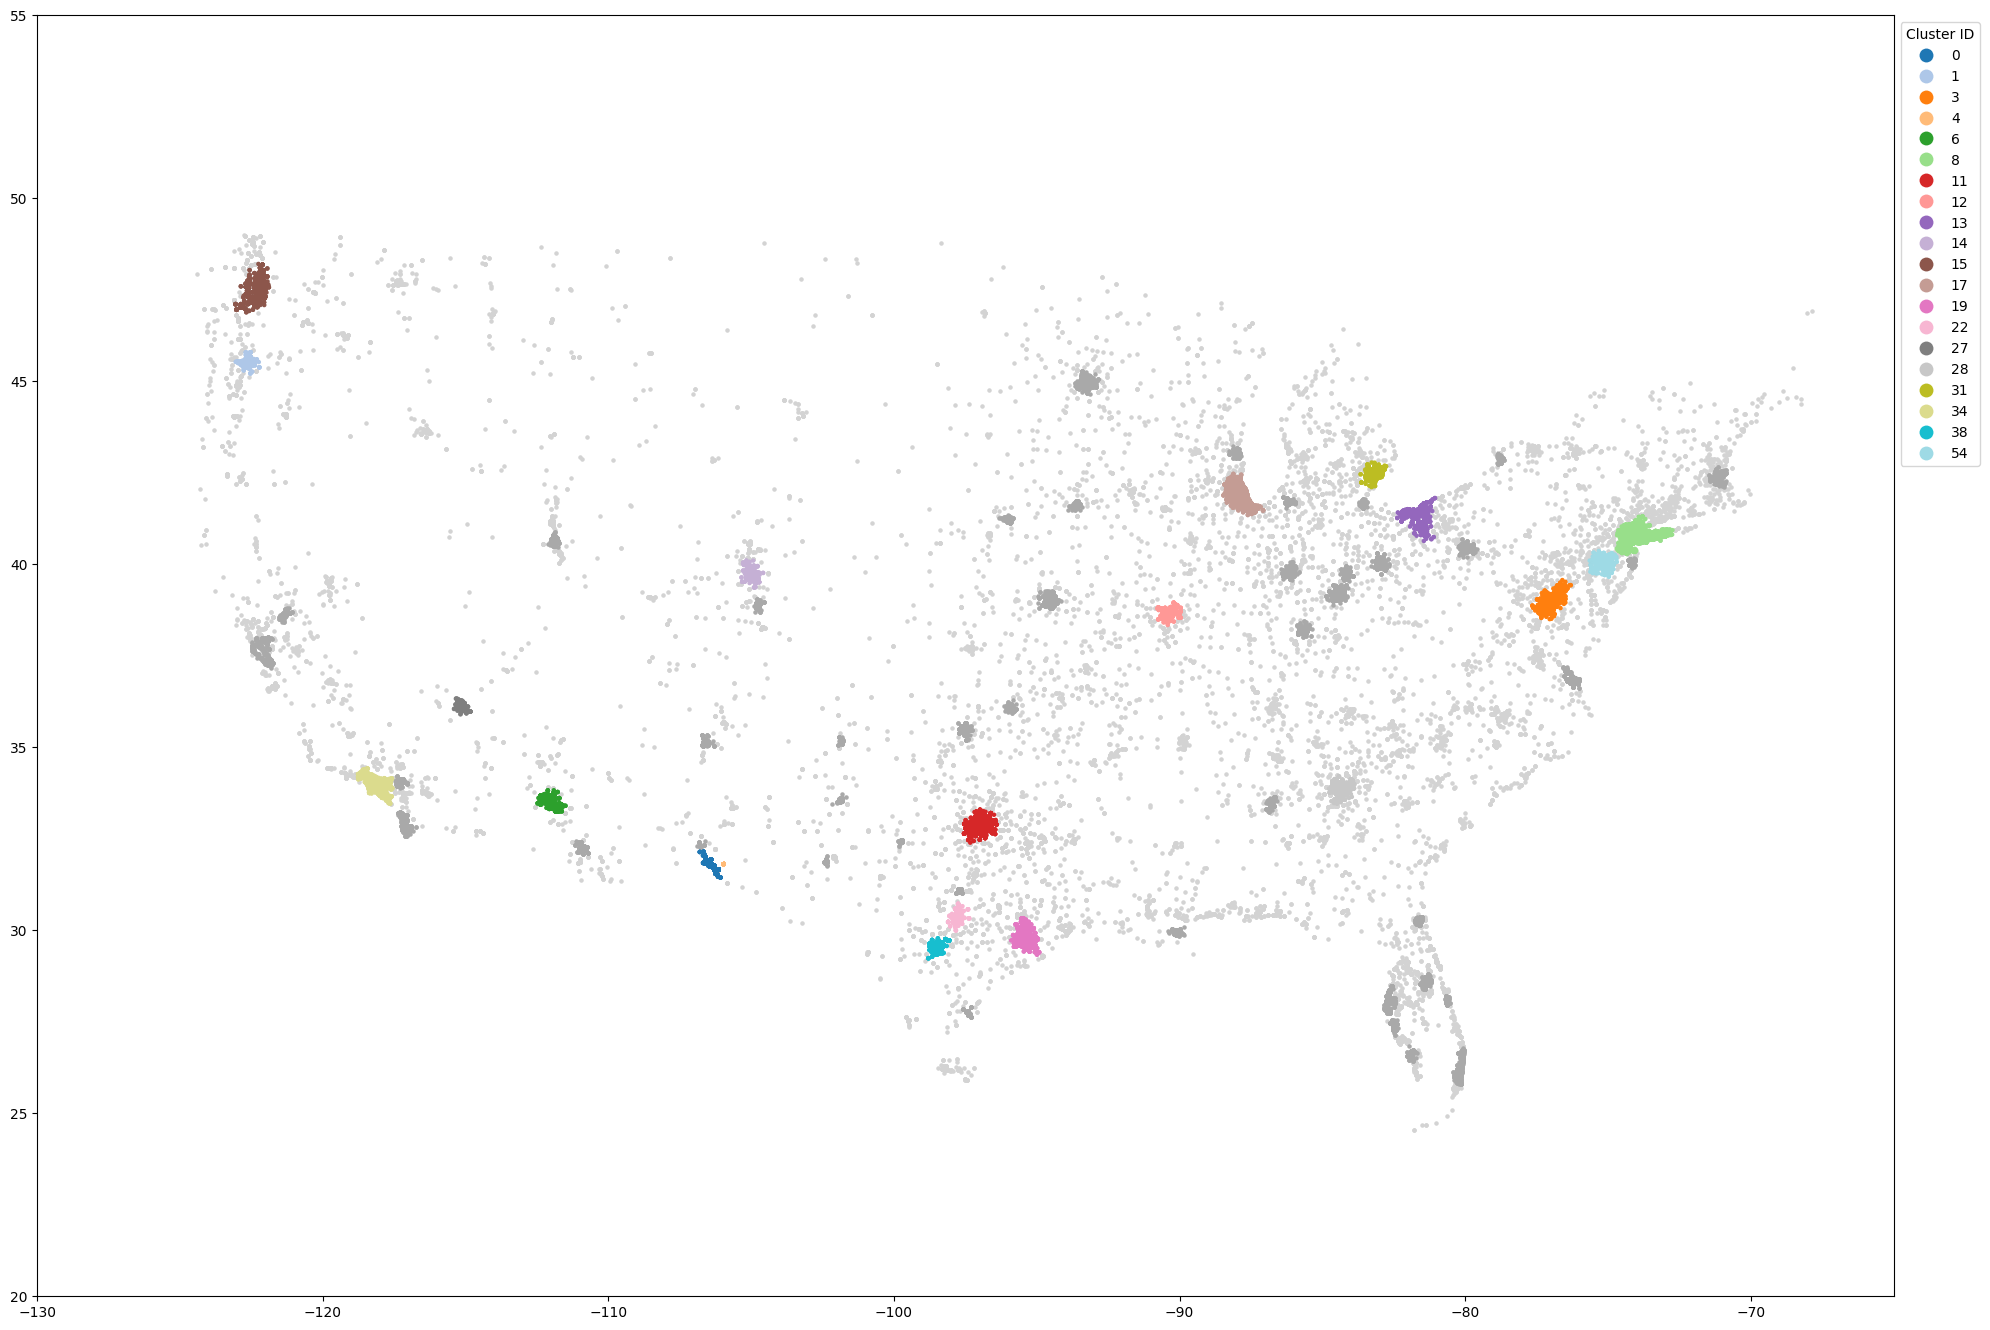

In [ ]:
# USE THIS ONE

# eps is based on meter measurement, so *1000 to get km
# 100 km = ~62 mi
# noise (not part of any cluster) = -1

db = DBSCAN(eps=16100, min_samples=50).fit(coords)     # 10 mi = 16.1 km
us_owners_5070['cluster_id'] = db.labels_

# CHECK RESULTS
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)
print(f"{n_clusters} clusters, {n_noise} noise points")
print(us_owners_5070[us_owners_5070['cluster_id'] != -1]['cluster_id'].value_counts().head(10))

# MAP
fig, ax = plt.subplots(figsize=(20, 14))
us_owners_4326 = us_owners_5070.to_crs('EPSG:4326')  # lat/lon for plotting on a recognizable map

# noise points in gray, clusters in color
noise = us_owners_4326[us_owners_4326['cluster_id'] == -1]
clustered = us_owners_4326[us_owners_4326['cluster_id'] != -1]

# only plot top 20 clusters to not run out of colors
top_clusters = clustered['cluster_id'].value_counts().head(20).index
clustered_top = clustered[clustered['cluster_id'].isin(top_clusters)].copy()
clustered_other = clustered[~clustered['cluster_id'].isin(top_clusters)]

noise.plot(ax=ax, color='lightgray', markersize=5, label='unclustered')
clustered_other.plot(ax=ax, color='darkgray', markersize=5)
clustered_top.plot(ax=ax, column='cluster_id', categorical=True, cmap='tab20',
                    markersize=5, legend=True,
                    legend_kwds={'title': 'Cluster ID', 'bbox_to_anchor': (1, 1)})

# set around continental US
ax.set_xlim(-130, -65)
ax.set_ylim(20, 55)
plt.tight_layout()
plt.show()

# noise.plot(ax=ax, color='lightgray', markersize=2, label='unclustered')
# clustered.plot(ax=ax, column='cluster_id', categorical=True, cmap='tab20', markersize=4, legend=True)
# plt.show()

148 clusters, 11093 noise points
cluster_id
3     2496
12    2350
15    1453
23    1384
21    1205
25    1195
4     1087
6      895
19     756
43     649
Name: count, dtype: int64


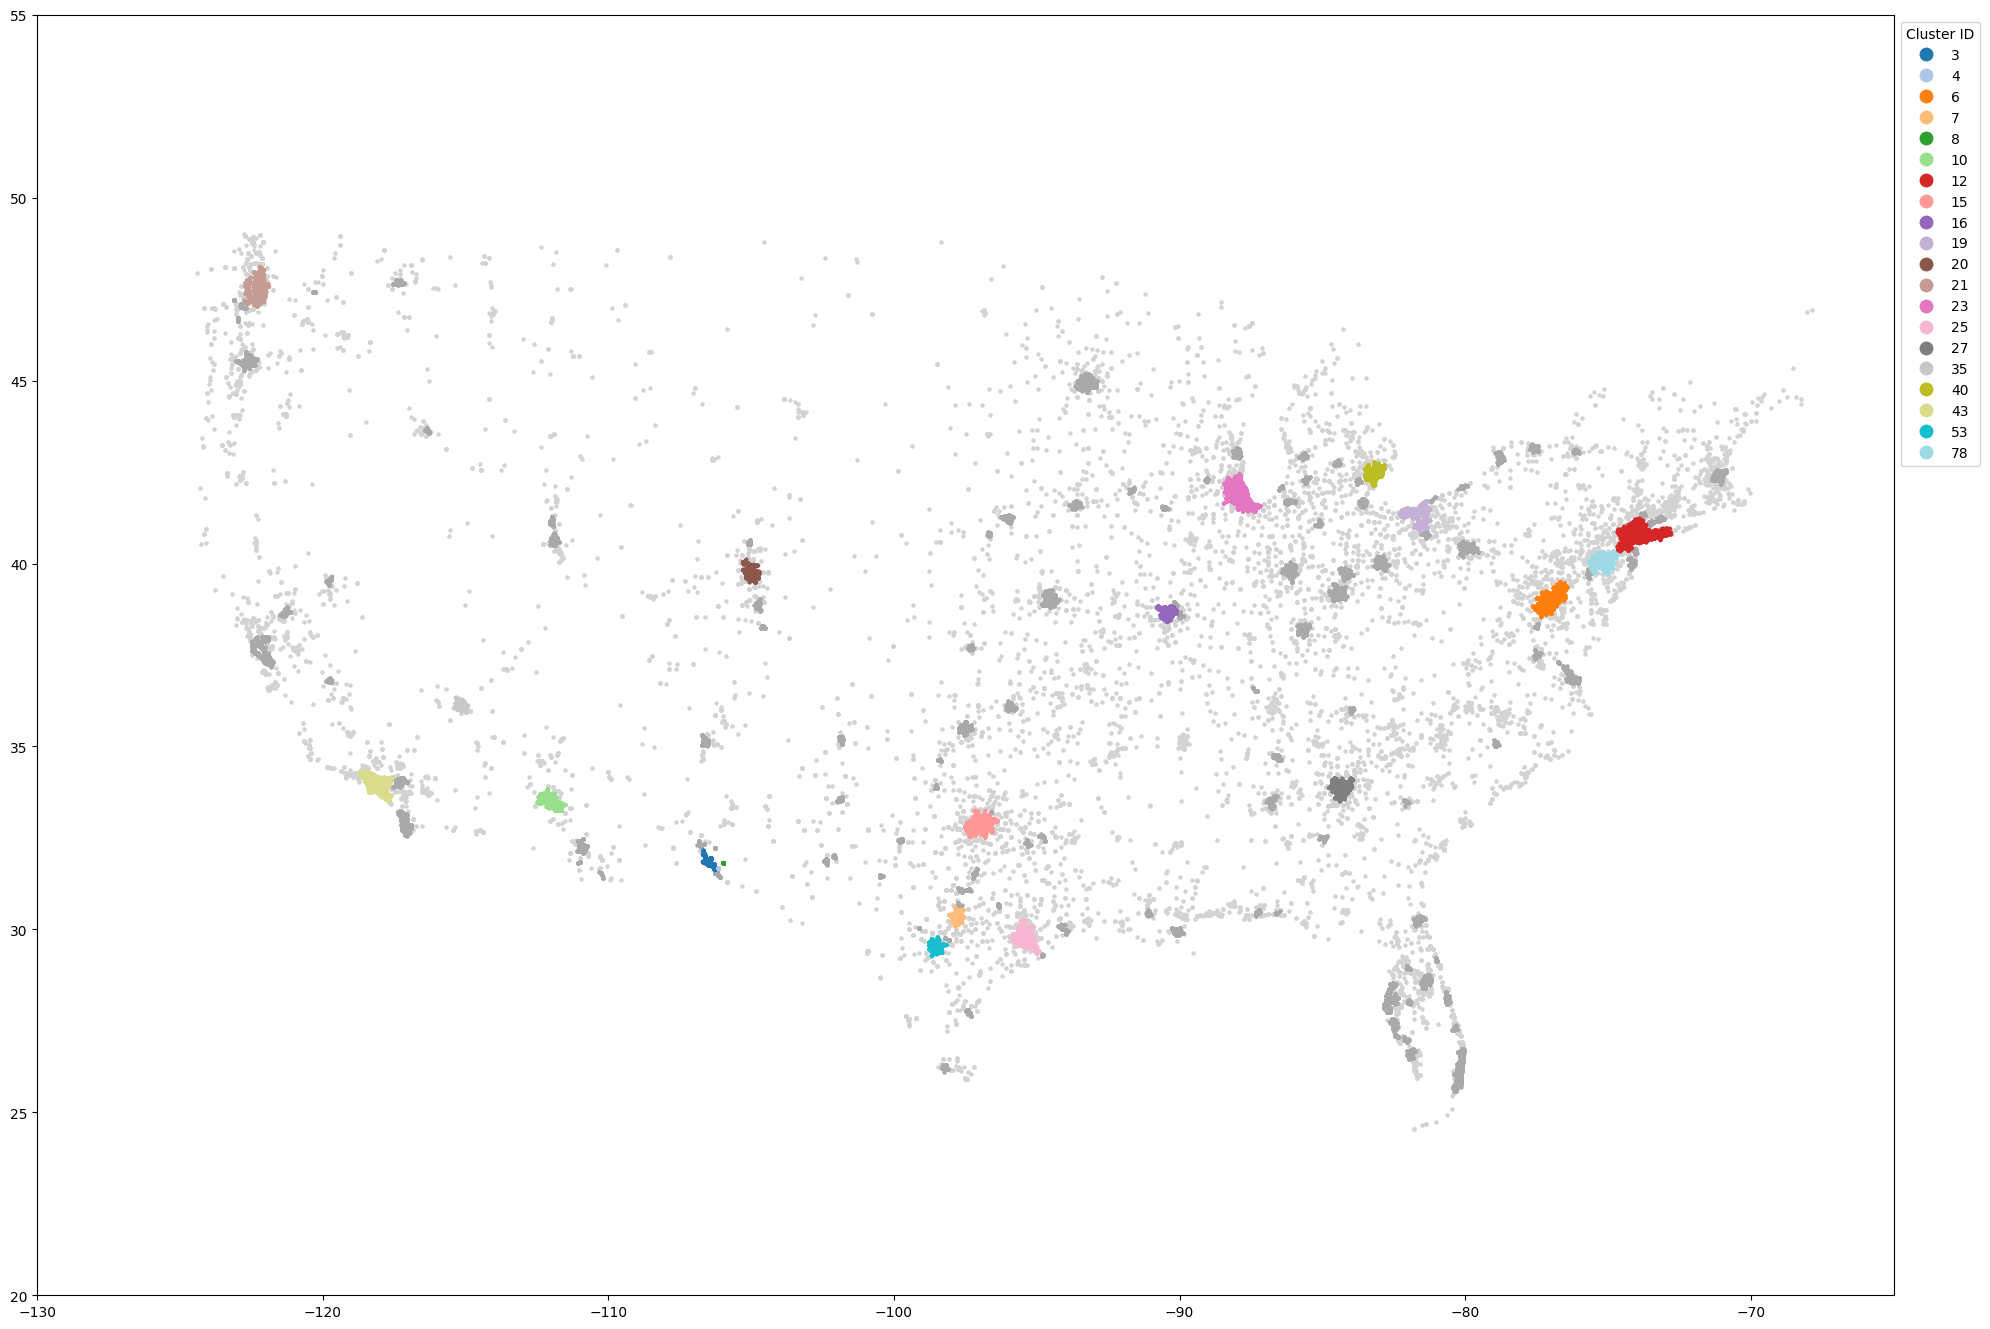

In [ ]:
# DON'T USE THIS ONE
# smaller eps and min_samples as a comparison - leads to more clusters

db = DBSCAN(eps=10000, min_samples=20).fit(coords)    # 10 km
us_owners_5070['cluster_id'] = db.labels_

# CHECK RESULTS
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)
print(f"{n_clusters} clusters, {n_noise} noise points")
print(us_owners_5070[us_owners_5070['cluster_id'] != -1]['cluster_id'].value_counts().head(10))

# MAP
fig, ax = plt.subplots(figsize=(20, 14))
us_owners_4326 = us_owners_5070.to_crs('EPSG:4326')  # lat/lon for plotting on a recognizable map

# noise points in gray, clusters in color
noise = us_owners_4326[us_owners_4326['cluster_id'] == -1]
clustered = us_owners_4326[us_owners_4326['cluster_id'] != -1]

# only plot top 20 clusters to not run out of colors
top_clusters = clustered['cluster_id'].value_counts().head(20).index
clustered_top = clustered[clustered['cluster_id'].isin(top_clusters)].copy()
clustered_other = clustered[~clustered['cluster_id'].isin(top_clusters)]

noise.plot(ax=ax, color='lightgray', markersize=5, label='unclustered')
clustered_other.plot(ax=ax, color='darkgray', markersize=5)
clustered_top.plot(ax=ax, column='cluster_id', categorical=True, cmap='tab20',
                    markersize=5, legend=True,
                    legend_kwds={'title': 'Cluster ID', 'bbox_to_anchor': (1, 1)})

# set around continental US
ax.set_xlim(-130, -65)
ax.set_ylim(20, 55)
plt.tight_layout()
plt.show()

64 clusters, 8564 noise points
cluster_id_hdbscan
63    2433
47    1663
60    1581
6     1578
45    1470
14    1087
57     991
56     990
41     868
8      845
Name: count, dtype: int64


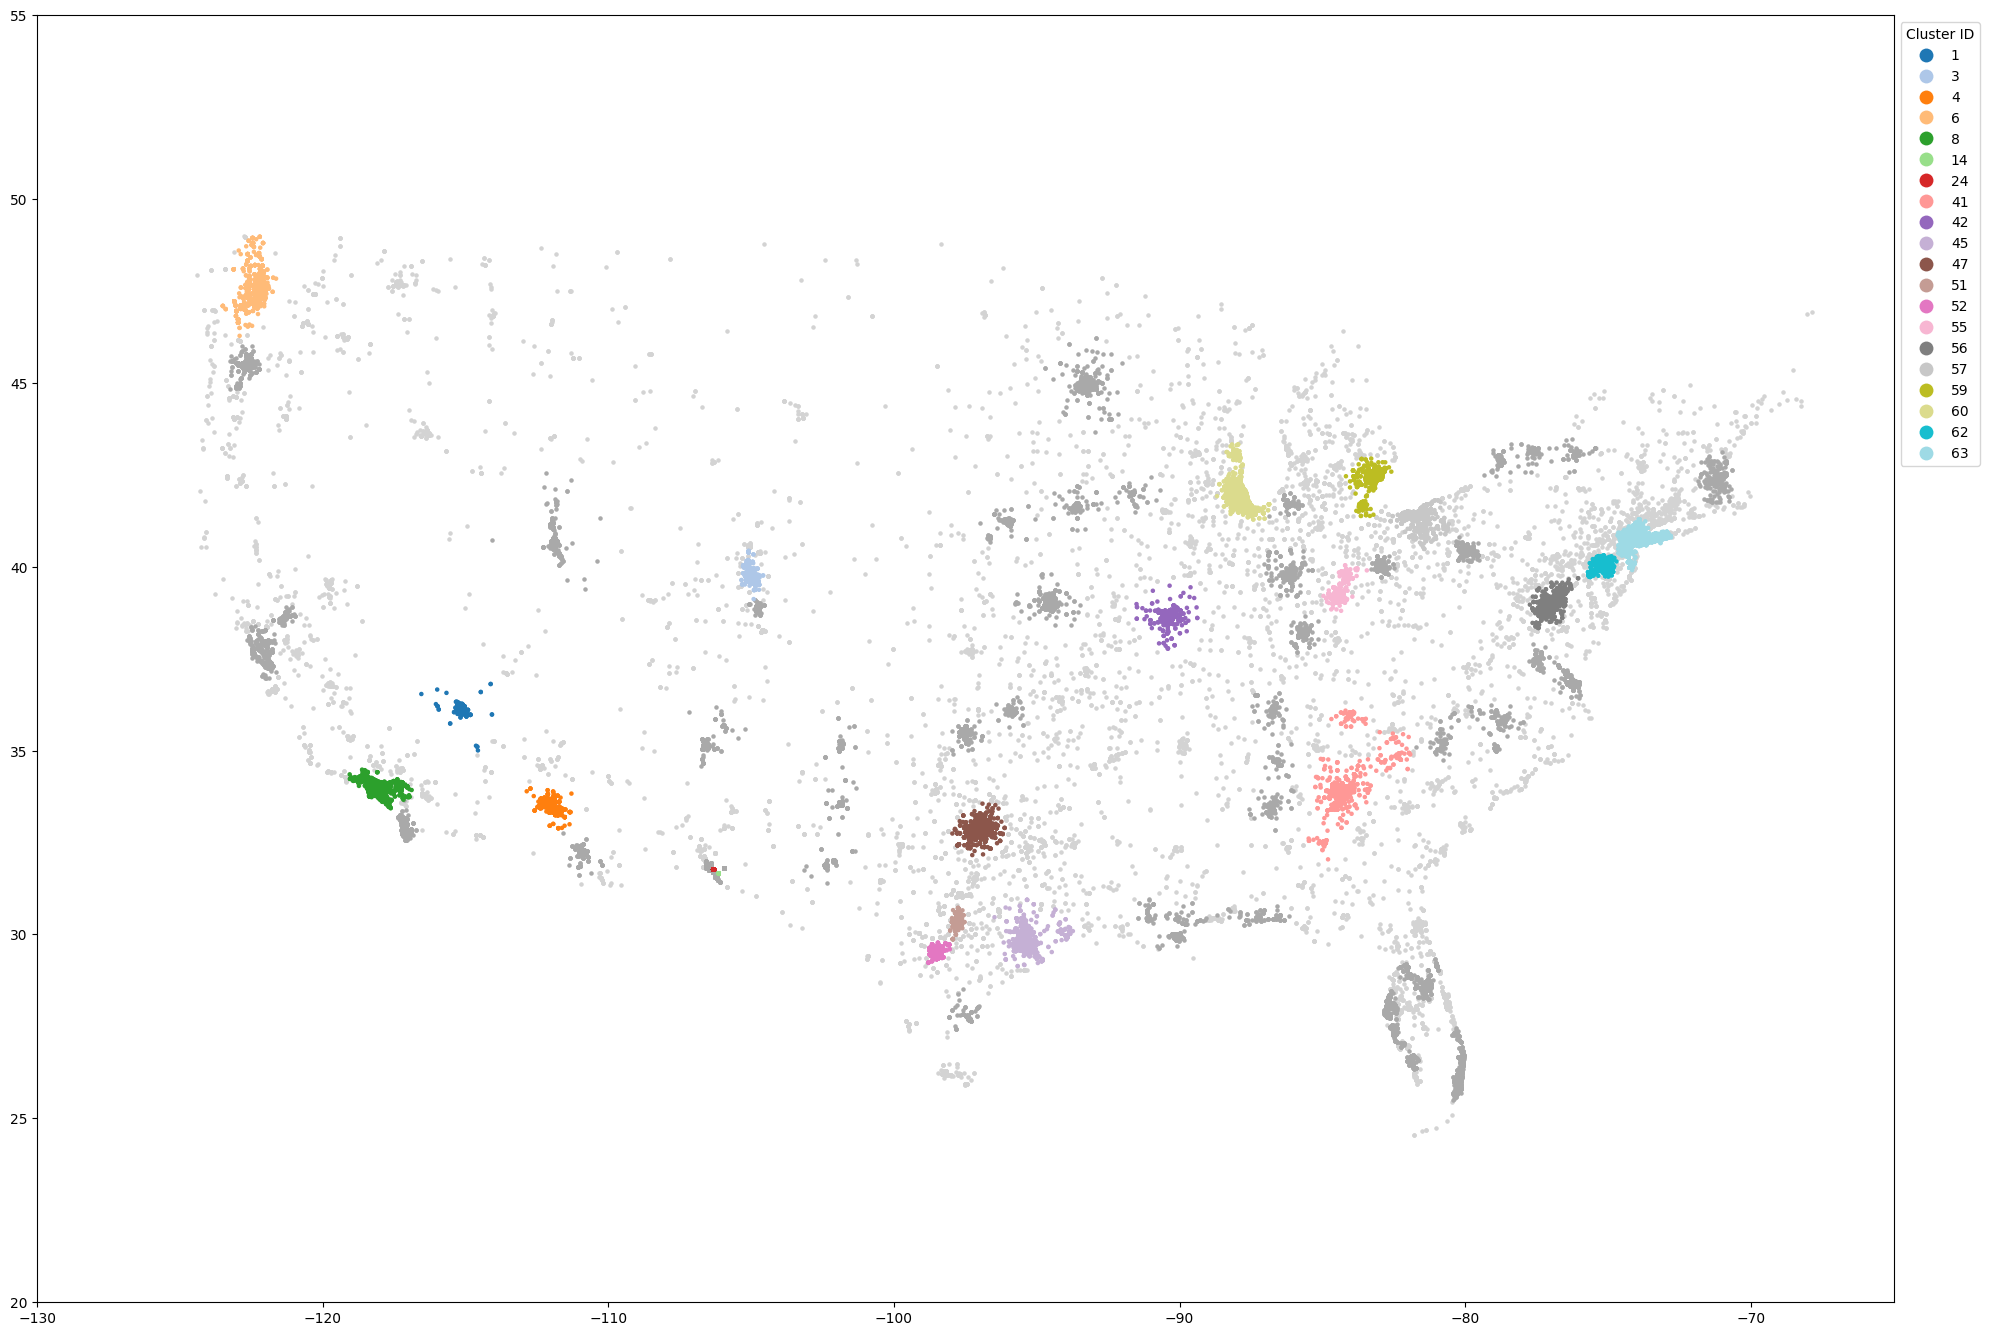

In [ ]:
# DON'T USE THIS ONE
# try same thing as above but with HDBSCAN, which allows variable distances between clusters (we don't set epsilon)

from sklearn.cluster import HDBSCAN

# min_cluster_size = min number of points for a group to be a cluster
# min_samples = more of a smoothing parameter, higher -> stricter density criteria for cluster, lower -> more willing to call sparser area a cluster

clusterer = HDBSCAN(min_cluster_size=100, min_samples=50)
labels = clusterer.fit_predict(coords)
us_owners_5070['cluster_id_hdbscan'] = labels

# CHECK RESULTS
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"{n_clusters} clusters, {n_noise} noise points")
print(us_owners_5070[us_owners_5070['cluster_id_hdbscan'] != -1]['cluster_id_hdbscan'].value_counts().head(10))

# MAP
fig, ax = plt.subplots(figsize=(20, 14))
us_owners_4326 = us_owners_5070.to_crs('EPSG:4326')  # lat/lon for plotting on a recognizable map

# noise points in gray, clusters in color
noise = us_owners_4326[us_owners_4326['cluster_id_hdbscan'] == -1]
clustered = us_owners_4326[us_owners_4326['cluster_id_hdbscan'] != -1]

# only plot top 20 clusters to not run out of colors
top_clusters = clustered['cluster_id_hdbscan'].value_counts().head(20).index
clustered_top = clustered[clustered['cluster_id_hdbscan'].isin(top_clusters)].copy()
clustered_other = clustered[~clustered['cluster_id_hdbscan'].isin(top_clusters)]

noise.plot(ax=ax, color='lightgray', markersize=5, label='unclustered')
clustered_other.plot(ax=ax, color='darkgray', markersize=5)
clustered_top.plot(ax=ax, column='cluster_id_hdbscan', categorical=True, cmap='tab20',
                    markersize=5, legend=True,
                    legend_kwds={'title': 'Cluster ID', 'bbox_to_anchor': (1, 1)})

# set around continental US
ax.set_xlim(-130, -65)
ax.set_ylim(20, 55)
plt.tight_layout()
plt.show()

sub_cluster_id
1    292
4     59
7     58
2     44
5     44
0     32
6     29
8     28
3     23
9     22
Name: count, dtype: int64


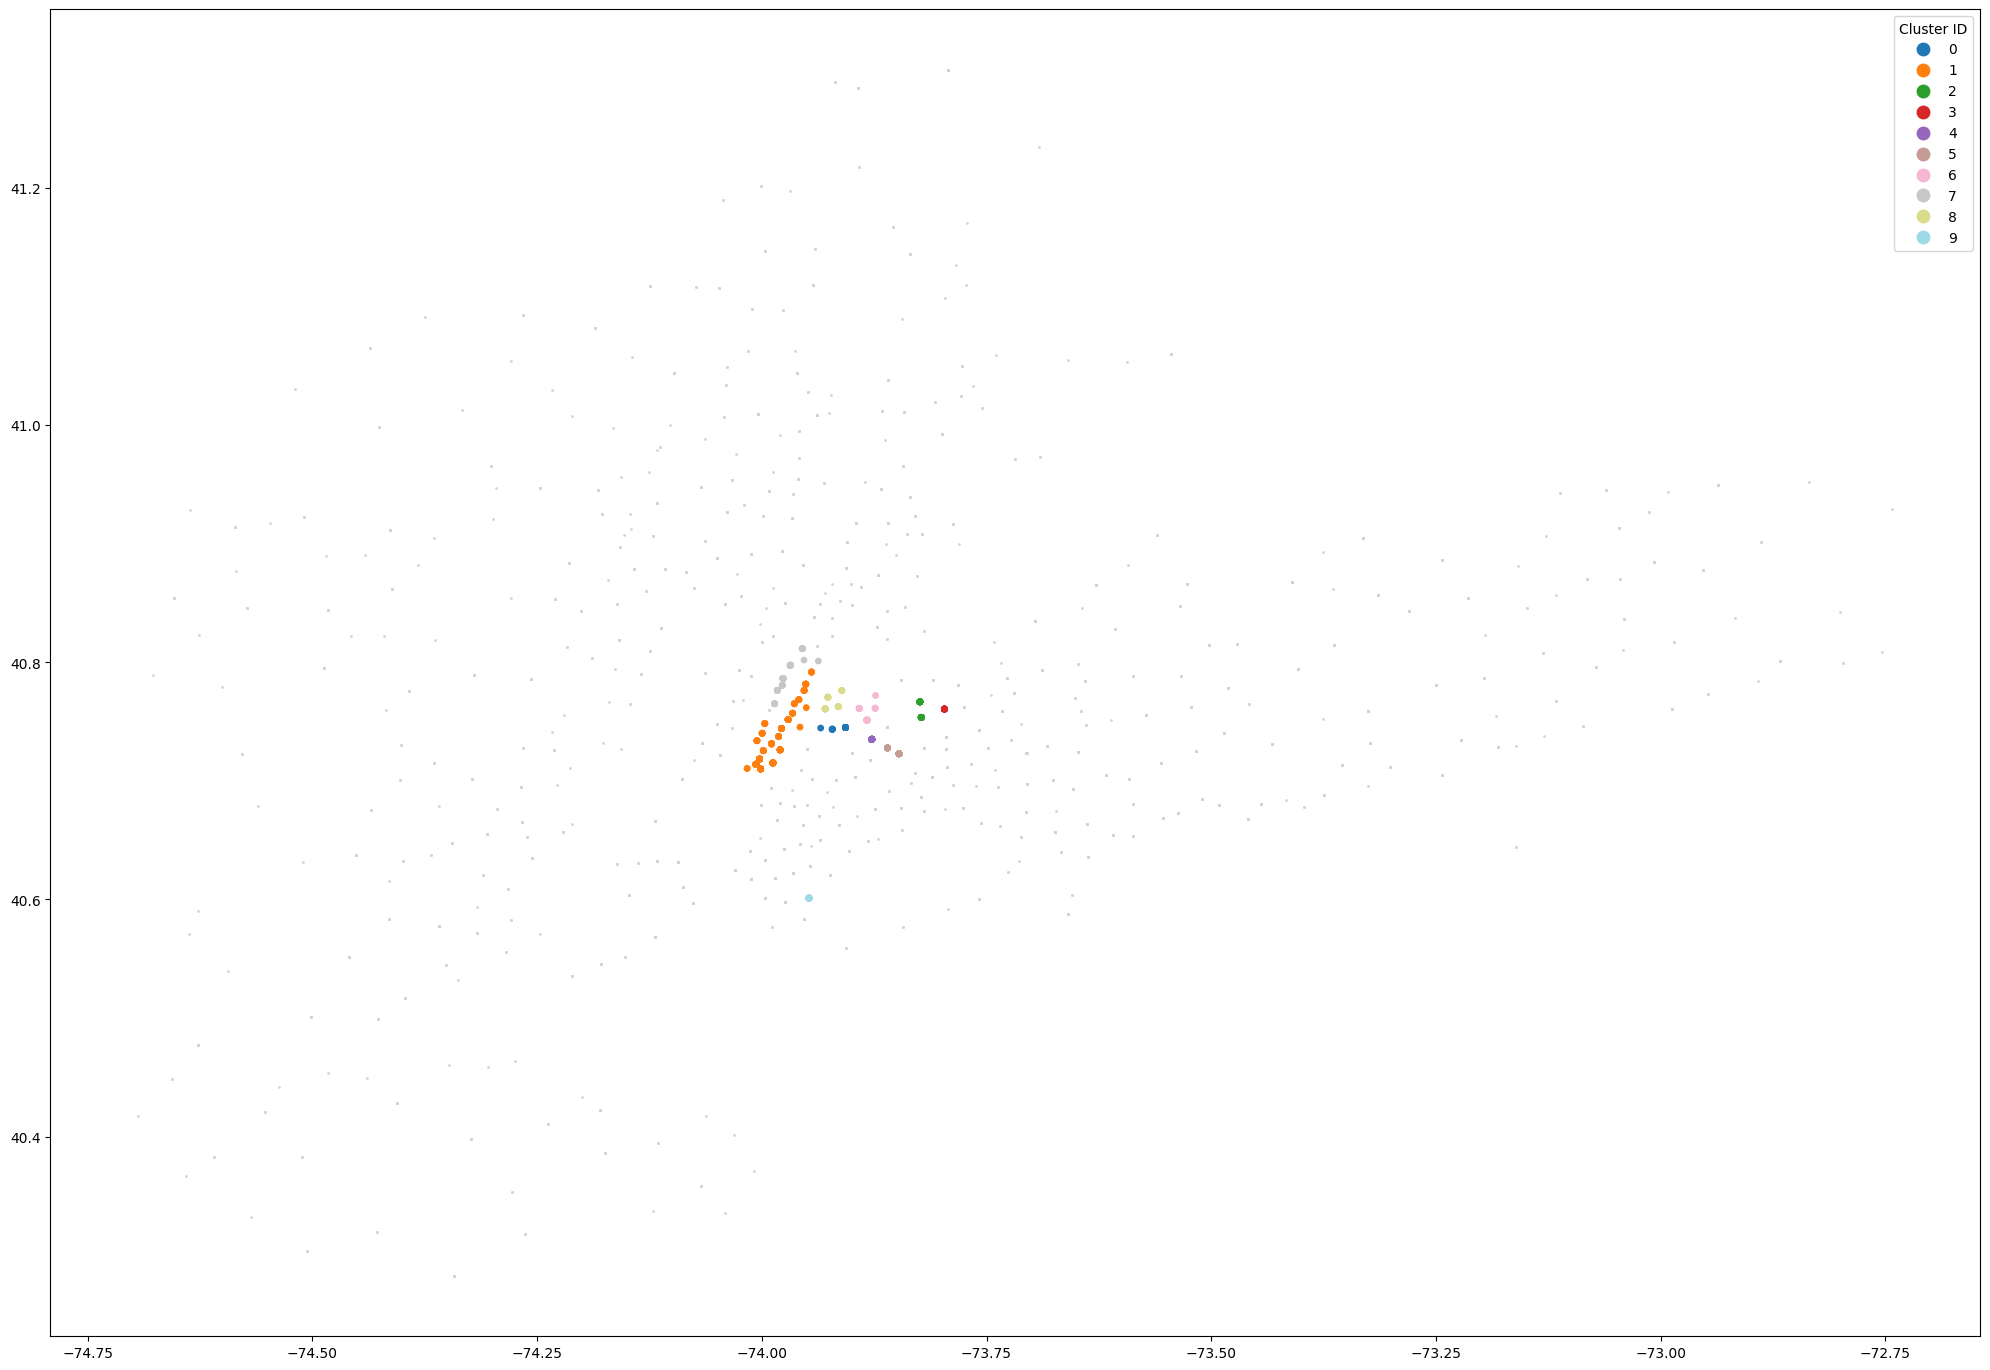

In [ ]:
# DON'T USE THIS ONE
# zoom in on the nj-ny metro cluster 8

ny_nj_cluster = us_owners_5070[us_owners_5070['cluster_id'] == 8].to_crs('EPSG:32618') # NY/NJ specific projected crs
sub_coords = ny_nj_cluster.geometry.get_coordinates().values

# db_zoomed = DBSCAN(eps=5000, min_samples=20).fit(sub_coords)
db_zoomed = DBSCAN(eps=1600, min_samples=20).fit(sub_coords)   # closer cluster for nyc
ny_nj_cluster['sub_cluster_id'] = db_zoomed.labels_

sub_sizes = ny_nj_cluster[ny_nj_cluster['sub_cluster_id'] != -1]['sub_cluster_id'].value_counts()
print(sub_sizes.head(20))

fig, ax = plt.subplots(figsize=(20, 14))
ny_nj_4326 = ny_nj_cluster.to_crs('EPSG:4326')

noise = ny_nj_4326[ny_nj_4326['sub_cluster_id'] == -1]
clustered = ny_nj_4326[ny_nj_4326['sub_cluster_id'] != -1]

noise.plot(ax=ax, color='lightgray', markersize=1, label='unclustered')
clustered.plot(ax=ax, column='sub_cluster_id', categorical=True, cmap='tab20',
                    markersize=15, legend=True,
                    legend_kwds={'title': 'Cluster ID', 'bbox_to_anchor': (1, 1)})
# ax.set_xlim(-74.15, -73.50)
# ax.set_ylim(40.55, 41)
plt.tight_layout()
plt.show()

12 clusters, 1404 noise points
sub_cluster_id
8     138
7     115
6      98
5      97
0      96
11     92
9      76
1      71
4      60
3      56
2      54
10     53
Name: count, dtype: int64


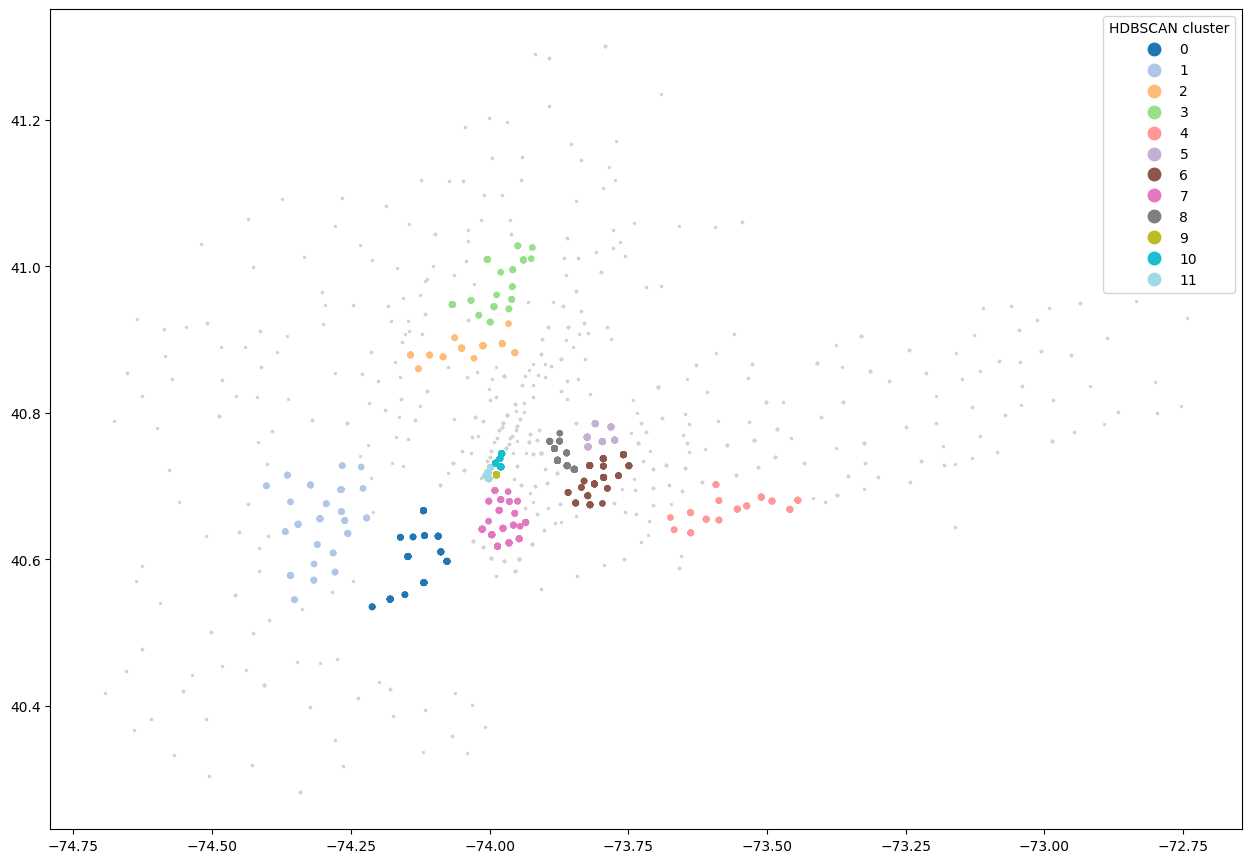

In [40]:
# USE THIS ONE
# try same thing as above but with HDBSCAN

# min_cluster_size = min number of points for a group to be a cluster
# min_samples = more of a smoothing parameter, higher -> stricter density criteria for cluster, lower -> more willing to call sparser area a cluster

clusterer = HDBSCAN(min_cluster_size=50, min_samples=10)
labels = clusterer.fit_predict(sub_coords)

ny_nj_cluster['sub_cluster_id'] = labels
ny_nj_cluster['cluster_probability'] = clusterer.probabilities_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"{n_clusters} clusters, {n_noise} noise points")
print(ny_nj_cluster[ny_nj_cluster['sub_cluster_id'] != -1]['sub_cluster_id'].value_counts().head(20))

ny_nj_4326 = ny_nj_cluster.to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(14, 12))

noise = ny_nj_4326[ny_nj_4326['sub_cluster_id'] == -1]
clustered = ny_nj_4326[ny_nj_4326['sub_cluster_id'] != -1]

noise.plot(ax=ax, color='lightgray', markersize=2, label='noise')
clustered.plot(ax=ax, column='sub_cluster_id', categorical=True, cmap='tab20',
               markersize=15, legend=True,
               legend_kwds={'title': 'HDBSCAN cluster', 'bbox_to_anchor': (1, 1)})
plt.tight_layout()
plt.show()

## Exporting geopackages with clusters

### Owner clusters on US/world map, owner geometry

In [ ]:
unique_us_owners_points_clustered = us_owners_5070.to_crs('4326') # back to lat/lon for consistency with other datasets
unique_us_owners_points_clustered.to_file('data/geodata_clean/unique_us_owners_points_clustered.gpkg', driver='GPKG')

### Parcels by cluster, parcel geometry

Attaching `cluster_id` to existing parcel geometry: Because `us_owners_5070` (which is from `unique_us_owners_points`) has only owner_geometry and not parcel_geometry, we need to join `us_owners_parcels` (the non-deduped parcel data) to `cluster_id` and any other new columns. We can join on `mail_key`

In [34]:
us_owners_parcels = gpd.read_file('geodata_clean/us_owners_parcels.gpkg')

Add `cluster_id` for national clusters

In [35]:
# pull mail_key (to join on) and cluster_id (which we want to attach) from us_owners_5070

cluster_lookup = us_owners_5070[['mail_key', 'cluster_id']]

In [36]:
us_owners_parcels = us_owners_parcels.merge(cluster_lookup, on='mail_key', how='left')
us_owners_parcels.head()

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,original_area,clipped_area,pct_inside,saleyear,is_entity,mail_zip_5,geo_country,owner_place_name,owner_state_name,owner_latitude,owner_longitude,mail_zip_3,mail_key,owner_dist_km,owner_dist_mi,geometry,cluster_id
0,48141,259289,259289,None,None,None,H79300301700100,387406,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,335.0,335.0,0.0,0.0,1981-12-01,NaN,2025,NaT,None,SALVADOR CONRADO C & TERESI,None,None,None,None,None,None,None,PO BOX 6739,None,NaN,6739,NaN,PO BOX,NaN,NaN,None,TAMUNING,GU,96931-6739,None,None,"{""mailadd"":""PO BOX 6739"",""mail_city"":""TAMUNING...",NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,"{""address"":"""",""szip"":""79928""}",el-paso-east,el-paso,TX,79928,79928,None,None,county,17 HORIZON VIEW ESTATES #3 LOT 10 ( 13950.00 S...,None,None,None,None,None,None,None,None,31.643919,-106.147618,Yes,48141010344,48141010334,481410103341000,481410103341,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.3202,NaN,0.29700,12938,None,None,None,NaT,/us/tx/el-paso/el-paso-east/40896,parcelnumb,dfbe8877-e20d-4f3c-8e06-42047c0952f2,None,2026-03-27 04:45:14.213000+00:00,H79300301700100,NaN,NaN,None,None,NaN,None,t23c,7,NaN,259289.0,eastc06,H7933,NaN,2025.0,H79300301700100,Residential,SEA150,H7933,387406,TDC62,ICL,SCC,NaN,SF1,SWE,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,335.0,0.0,0.0,335.0,0.0,335.0,1201.956666,1201.956666,1.0,1981.0,False,96931,GU,Tamuning,Gu,13.4443,144.7863,969,PO BOX 6739|96931,10972.004228,6817.704294,"MULTIPOLYGON (((-106.14783 31.64407, -106.1478...",-1.0
1,48141,202403,202403,None,None,None,H79300301700090,387406,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,331.0,331.0,0.0,0.0,1981-12-01,NaN,2025,NaT,None,SALVADOR CONRADO C & TERESI,None,None,None,None,None,None,None,PO BOX 6739,None,NaN,6739,NaN,PO BOX,NaN,NaN,None,TAMUNING,GU,96931-6739,None,None,"{""mailadd"":""PO BOX 6739"",""mail_city"":""TAMUNING...",NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,"{""address"":"""",""szip"":""79928""}",el-paso-east,el-paso,TX,79928,79928,None,None,county,17 HORIZON VIEW ESTATES #3 LOT 9 ( 13800.00 SQ...,None,None,None,None,None,None,None,None,31.644147,-106.147470,Yes,48141010344,48141010334,481410103341000,481410103341,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.3168,NaN,0.29150,12698,None,None,None,NaT,/us/tx/el-p

In [ ]:
# some parcels will have no cluster_id because I didn't remove the failed geocoded owners from us_owners_parcels, but it's ok to keep them since they just won't appear in a cluster

us_owners_parcels['cluster_id'].isna().sum()

np.int64(180)

In [38]:
us_owners_parcels.to_file('geodata_clean/us_owners_parcels_clustered.gpkg', driver='GPKG')

Add `sub_cluster_id` for NY/NJ cluster

In [41]:
sub_cluster_lookup = ny_nj_cluster[['mail_key', 'sub_cluster_id', 'cluster_probability']]

In [42]:
us_owners_parcels = us_owners_parcels.merge(sub_cluster_lookup, on='mail_key', how='left')
us_owners_parcels.head(1)

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,original_area,clipped_area,pct_inside,saleyear,is_entity,mail_zip_5,geo_country,owner_place_name,owner_state_name,owner_latitude,owner_longitude,mail_zip_3,mail_key,owner_dist_km,owner_dist_mi,geometry,cluster_id,sub_cluster_id,cluster_probability
0,48141,259289,259289,None,None,None,H79300301700100,387406,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,335.0,335.0,0.0,0.0,1981-12-01,NaN,2025,NaT,None,SALVADOR CONRADO C & TERESI,None,None,None,None,None,None,None,PO BOX 6739,None,NaN,6739,NaN,PO BOX,NaN,NaN,None,TAMUNING,GU,96931-6739,None,None,"{""mailadd"":""PO BOX 6739"",""mail_city"":""TAMUNING...",NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,"{""address"":"""",""szip"":""79928""}",el-paso-east,el-paso,TX,79928,79928,None,None,county,17 HORIZON VIEW ESTATES #3 LOT 10 ( 13950.00 S...,None,None,None,None,None,None,None,None,31.643919,-106.147618,Yes,48141010344,48141010334,481410103341000,481410103341,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.3202,NaN,0.297,12938,None,None,None,NaT,/us/tx/el-paso/el-paso-east/40896,parcelnumb,dfbe8877-e20d-4f3c-8e06-42047c0952f2,None,2026-03-27 04:45:14.213000+00:00,H79300301700100,NaN,NaN,None,None,NaN,None,t23c,7,NaN,259289.0,eastc06,H7933,NaN,2025.0,H79300301700100,Residential,SEA150,H7933,387406,TDC62,ICL,SCC,NaN,SF1,SWE,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,335.0,0.0,0.0,335.0,0.0,335.0,1201.956666,1201.956666,1.0,1981.0,False,96931,GU,Tamuning,Gu,13.4443,144.7863,969,PO BOX 6739|96931,10972.004228,6817.704294,"MULTIPOLYGON (((-106.14783 31.64407, -106.1478...",-1.0,NaN,NaN


In [43]:
us_owners_parcels.to_file('geodata_clean/us_owners_parcels_subclustered.gpkg', driver='GPKG')

## Exporting viz-ready datasets

For datasets that will be rendered in browser with D3/Canvas, we'll keep only the columns needed and export as geoJSON

In [50]:
unique_us_owners_points_clustered.head(1)

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,original_area,clipped_area,pct_inside,saleyear,is_entity,mail_zip_5,geo_country,owner_place_name,owner_state_name,owner_latitude,owner_longitude,mail_zip_3,mail_key,owner_dist_km,owner_dist_mi,owner_geometry,cluster_id,cluster_id_hdbscan
0,48141,259289,259289,None,None,None,H79300301700100,387406,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,335.0,335.0,0.0,0.0,1981-12-01,NaN,2025,NaT,None,SALVADOR CONRADO C & TERESI,None,None,None,None,None,None,None,PO BOX 6739,None,NaN,6739,NaN,PO BOX,NaN,NaN,None,TAMUNING,GU,96931-6739,None,None,"{""mailadd"":""PO BOX 6739"",""mail_city"":""TAMUNING...",NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,"{""address"":"""",""szip"":""79928""}",el-paso-east,el-paso,TX,79928,79928,None,None,county,17 HORIZON VIEW ESTATES #3 LOT 10 ( 13950.00 S...,None,None,None,None,None,None,None,None,31.643919,-106.147618,Yes,48141010344,48141010334,481410103341000,481410103341,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.3202,NaN,0.297,12938,None,None,None,NaT,/us/tx/el-paso/el-paso-east/40896,parcelnumb,dfbe8877-e20d-4f3c-8e06-42047c0952f2,None,2026-03-27 04:45:14.213000+00:00,H79300301700100,NaN,NaN,None,None,NaN,None,t23c,7,NaN,259289.0,eastc06,H7933,NaN,2025.0,H79300301700100,Residential,SEA150,H7933,387406,TDC62,ICL,SCC,NaN,SF1,SWE,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,335.0,0.0,0.0,335.0,0.0,335.0,1201.956666,1201.956666,1.0,1981.0,False,96931,GU,Tamuning,Gu,13.4443,144.7863,969,PO BOX 6739|96931,10972.004228,6817.704294,POINT (144.7863 13.4443),-1,-1


In [52]:
unique_us_owners_points_clustered_viz = unique_us_owners_points_clustered[['owner_geometry', 'cluster_id']]
unique_us_owners_points_clustered_viz.to_file('data/geodata_viz/unique_us_owners_points_clustered_viz.geojson', driver='GeoJSON')

In [53]:
us_owners_parcels.head(1)

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,original_area,clipped_area,pct_inside,saleyear,is_entity,mail_zip_5,geo_country,owner_place_name,owner_state_name,owner_latitude,owner_longitude,mail_zip_3,mail_key,owner_dist_km,owner_dist_mi,geometry,cluster_id,sub_cluster_id,cluster_probability
0,48141,259289,259289,None,None,None,H79300301700100,387406,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,335.0,335.0,0.0,0.0,1981-12-01,NaN,2025,NaT,None,SALVADOR CONRADO C & TERESI,None,None,None,None,None,None,None,PO BOX 6739,None,NaN,6739,NaN,PO BOX,NaN,NaN,None,TAMUNING,GU,96931-6739,None,None,"{""mailadd"":""PO BOX 6739"",""mail_city"":""TAMUNING...",NaN,None,NaN,None,NaN,NaN,None,NaN,NaN,"{""address"":"""",""szip"":""79928""}",el-paso-east,el-paso,TX,79928,79928,None,None,county,17 HORIZON VIEW ESTATES #3 LOT 10 ( 13950.00 S...,None,None,None,None,None,None,None,None,31.643919,-106.147618,Yes,48141010344,48141010334,481410103341000,481410103341,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.3202,NaN,0.297,12938,None,None,None,NaT,/us/tx/el-paso/el-paso-east/40896,parcelnumb,dfbe8877-e20d-4f3c-8e06-42047c0952f2,None,2026-03-27 04:45:14.213000+00:00,H79300301700100,NaN,NaN,None,None,NaN,None,t23c,7,NaN,259289.0,eastc06,H7933,NaN,2025.0,H79300301700100,Residential,SEA150,H7933,387406,TDC62,ICL,SCC,NaN,SF1,SWE,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,335.0,0.0,0.0,335.0,0.0,335.0,1201.956666,1201.956666,1.0,1981.0,False,96931,GU,Tamuning,Gu,13.4443,144.7863,969,PO BOX 6739|96931,10972.004228,6817.704294,"MULTIPOLYGON (((-106.14783 31.64407, -106.1478...",-1.0,NaN,NaN


In [55]:
us_owners_parcels_clustered_viz = us_owners_parcels[['geometry', 'cluster_id']]
us_owners_parcels_clustered_viz.to_file('data/geodata_viz/us_owners_parcels_clustered_viz.geojson', driver='GeoJSON')